In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_json("Sarcasm_Headlines_Dataset_v2.json", lines=True)
df.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [2]:
df = df[['headline', 'is_sarcastic']]
df.shape
df['is_sarcastic'].value_counts()

,count
is_sarcastic,
0,14985
1,13634


In [3]:
from sklearn.model_selection import train_test_split

X = df['headline']
y = df['is_sarcastic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:
print(X_train.shape)
print(X_test.shape)

(22895,)
(5724,)


In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print(X_train_seq[0])

[4797, 986, 4798, 22, 3225, 25, 687, 10, 1838, 4244, 1, 40, 1, 525, 3, 2585, 3226]


In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_padded = pad_sequences(X_train_seq, maxlen=50)
X_test_padded = pad_sequences(X_test_seq, maxlen=50)

X_train_padded.shape
X_train_padded[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
       4797,  986, 4798,   22, 3225,   25,  687,   10, 1838, 4244,    1,
         40,    1,  525,    3, 2585, 3226], dtype=int32)

In [15]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Embedding(5000, 32, input_length=50),
    layers.SimpleRNN(32),
    layers.Dense(1, activation='sigmoid')
])
model.build(input_shape=(None, 50))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,113 (633.25 KB)

 Trainable params: 162,113 (633.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [18]:
history = model.fit(
    X_train_padded, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7867 - loss: 0.4389 - val_accuracy: 0.8351 - val_loss: 0.3651
Epoch 2/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9053 - loss: 0.2359 - val_accuracy: 0.8390 - val_loss: 0.3757
Epoch 3/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9553 - loss: 0.1269 - val_accuracy: 0.8249 - val_loss: 0.4706
Epoch 4/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9830 - loss: 0.0563 - val_accuracy: 0.8244 - val_loss: 0.5858
Epoch 5/5
573/573 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9928 - loss: 0.0255 - val_accuracy: 0.8231 - val_loss: 0.7459


In [19]:
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test)
print("Test Accuracy:", test_accuracy)

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8263 - loss: 0.7008
Test Accuracy: 0.8263452053070068


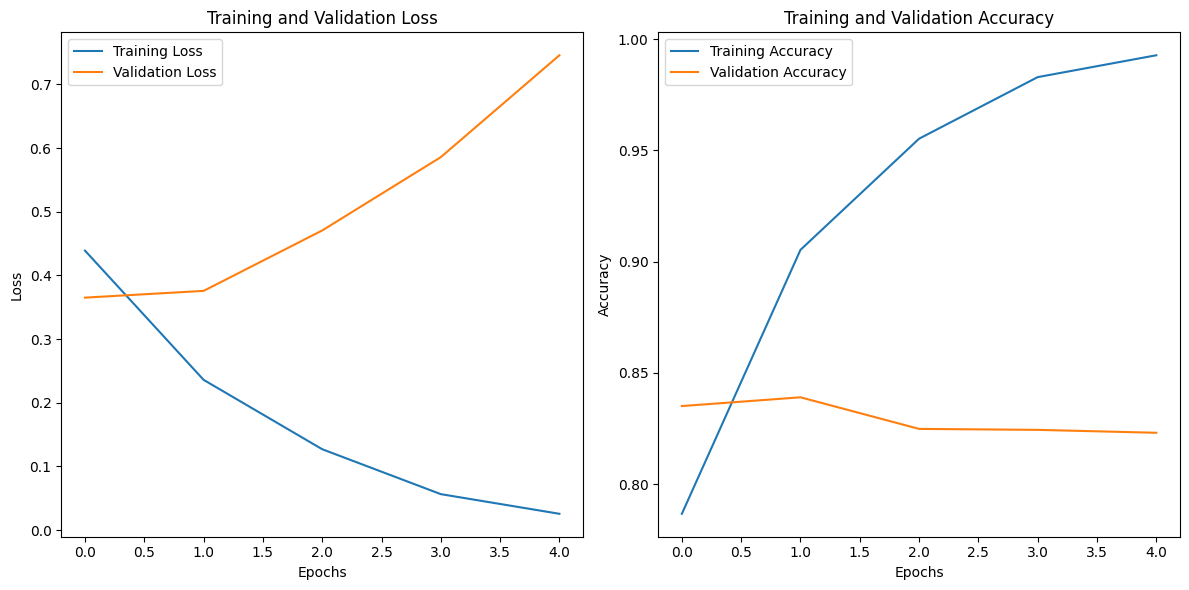

In [21]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.show()

Findings:



1.   Built the exact model (Embedding → SimpleRNN → Dense) on sarcasm headlines, trained for 5 epochs
2.   Training accuracy climbed all the way to 99%, but validation accuracy actually peaked early around epoch 1 (84%) then slowly dropped to 82.5%, classic overfitting, the model started memorizing the training headlines instead of learning general patterns



1.   Validation loss backs this up too, it dipped slightly then shot back up while training loss kept dropping the whole time
2.   Test accuracy landed at 82.6%, which lines up with the validation plateau, not the inflated training number, so that's the more honest measure of how well it actually generalizes



1.   Basically, when the RNN learns, it has to send the error signal backward through every single word in the sequence
2.   Each step shrinks that signal a little bit, so by the time it reaches the earlier words in a long sequence, there's barely anything left



1.   That means the model kind of forgets what happened early on and struggles to connect things that are far apart in the text









